# Preparação dos dados — Taxa de inflação por classe (PORDATA)

**Projeto:** O Preço da Guerra 
**Autor:** Luis Miguel Pereira Silva · PG60390 
**Universidade:** Universidade do Minho — Mestrado em IA 
**Disciplina:** SVDC 

---

## Fonte

[PORDATA / INE](https://www.pordata.pt/) — *Taxa de Inflação (Taxa de Variação do IPC): total e por consumo individual por objetivo*. Anual.

Ficheiro original: `data/PORDATA_Taxa-de-Inflação-(Taxa-de-Variação-do-IPC).xlsx`, sheet `Quadro` 
Ficheiro produzido: `data/inflacao_pordata.csv`

## Estrutura COICOP

A PORDATA disponibiliza a inflação por **classe COICOP** (Classification of Individual Consumption According to Purpose):

1. Total IPC
2. Total exceto produtos alimentares não transformados e produtos energéticos
3. Produtos alimentares e bebidas não alcoólicas
4. Bebidas alcoólicas e tabaco
5. Vestuário e calçado
6. Habitação, água, eletricidade, gás e outros combustíveis
7. Acessórios para o lar, equipamento doméstico e manutenção
8. Saúde
9. **Transportes** ← classe mais sensível ao preço do petróleo
10. Informação e comunicação
11. Lazer, recreação, desporto e cultura
12. Serviços de educação

(o ficheiro original tem 15 colunas, mas as últimas 3 — Restaurantes, Serviços financeiros, Serviços diversos — só têm dados a partir de 2018, 
por isso o CSV limpo guarda só as 12 primeiras classes para o storytelling).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
XLSX = RAW / 'pordata_taxa_inflacao.xlsx'


## 1. Ler a sheet `Quadro`

O header está na linha 7 (índice 7). A coluna 0 é `Anos`.


In [2]:
raw = pd.read_excel(XLSX, sheet_name='Quadro', header=7)
print('Shape inicial:', raw.shape)
raw.iloc[:, :13].head()


Shape inicial: (89, 256)


,Unnamed: 0,Total,Total exceto produtos alimentares não transformados e produtos energéticos,Produtos alimentares e bebidas não alcoólicas,Bebidas alcoólicas e tabaco,Vestuário e calçado,"Habitação, água, eletricidade, gás e outros combustíveis","Acessórios para o lar, equipamento doméstico e manutenção corrente da habitação",Saúde,Transportes,Informação e comunicação,"Lazer, recreação, desporto e cultura",Serviços de educação
0,1960,2.6,2.3,3.2,0.1,1.5,3.4,1.9,1,1.4,0,-0.8,-0.1
1,1961,0.5,2,-1.5,1.1,1.1,4.6,2.6,-0.1,1.1,0,-0.5,-0.3
2,1962,2.4,1.2,2.7,5.9,-0.7,1.9,4,4.3,4.1,0,0,0
3,1963,1.7,0.5,3.4,-2.3,-0.3,-0.4,2.4,0.6,3.4,0,0.9,0.1
4,1964,3.1,2.7,4.3,-1.2,0.5,3.8,3,-0.2,0.7,0,0.6,0.3


## 2. Limpeza

- Renomear `Unnamed: 0` para `ano`
- Manter só as 12 classes principais (col 0 a col 12)
- Encurtar nomes longos (ficam mais limpos para gráficos)
- Filtrar linhas que não são anos (notas de rodapé, células vazias)


In [3]:
df = raw.iloc[:, :13].copy()
df.rename(columns={df.columns[0]: 'ano'}, inplace=True)

# Encurtar nomes
rename_map = {
    'Total exceto produtos alimentares não transformados e produtos energéticos': 'Total exceto alimentares e energéticos',
    'Habitação, água, eletricidade, gás e outros combustíveis': 'Habitação, água, eletricidade, gás e outros combustíveis',
    'Acessórios para o lar, equipamento doméstico e manutenção corrente da habitação': 'Acessórios para o lar e equipamento doméstico',
    'Lazer, recreação, desporto e cultura': 'Lazer, recreação, desporto e cultura',
}
df.rename(columns=rename_map, inplace=True)

# Manter só linhas em que `ano` é número entre 1960 e 2030
df['ano'] = pd.to_numeric(df['ano'], errors='coerce')
df = df[df['ano'].between(1960, 2030)].reset_index(drop=True)
df['ano'] = df['ano'].astype(int)

# Restantes colunas → numérico
for c in df.columns[1:]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(f'Linhas: {len(df)} (de {df.ano.min()} a {df.ano.max()})')
df.head()


Linhas: 66 (de 1960 a 2025)


,ano,Total,Total exceto alimentares e energéticos,Produtos alimentares e bebidas não alcoólicas,Bebidas alcoólicas e tabaco,Vestuário e calçado,"Habitação, água, eletricidade, gás e outros combustíveis",Acessórios para o lar e equipamento doméstico,Saúde,Transportes,Informação e comunicação,"Lazer, recreação, desporto e cultura",Serviços de educação
0,1960,2.6,2.3,3.2,0.1,1.5,3.4,1.9,1.0,1.4,0.0,-0.8,-0.1
1,1961,0.5,2.0,-1.5,1.1,1.1,4.6,2.6,-0.1,1.1,0.0,-0.5,-0.3
2,1962,2.4,1.2,2.7,5.9,-0.7,1.9,4.0,4.3,4.1,0.0,0.0,0.0
3,1963,1.7,0.5,3.4,-2.3,-0.3,-0.4,2.4,0.6,3.4,0.0,0.9,0.1
4,1964,3.1,2.7,4.3,-1.2,0.5,3.8,3.0,-0.2,0.7,0.0,0.6,0.3


## 3. Sanity checks

Comparar com episódios conhecidos:
- **1973 / 1979** — choques petrolíferos: inflação >20% em Transportes
- **2008** — pico do petróleo (147 USD/barril)
- **2022** — invasão russa da Ucrânia


In [4]:
marcos = df[df['ano'].isin([1973, 1979, 1980, 2008, 2022, 2024])][['ano', 'Total', 'Transportes']]
print(marcos.to_string(index=False))


 ano  Total  Transportes
1973   13.0         23.3
1979   21.7         18.5
1980   16.1         26.9
2008    2.6          1.5
2022    7.8         10.0
2024    2.4          1.4


## 4. Visualização rápida — Transportes vs Total


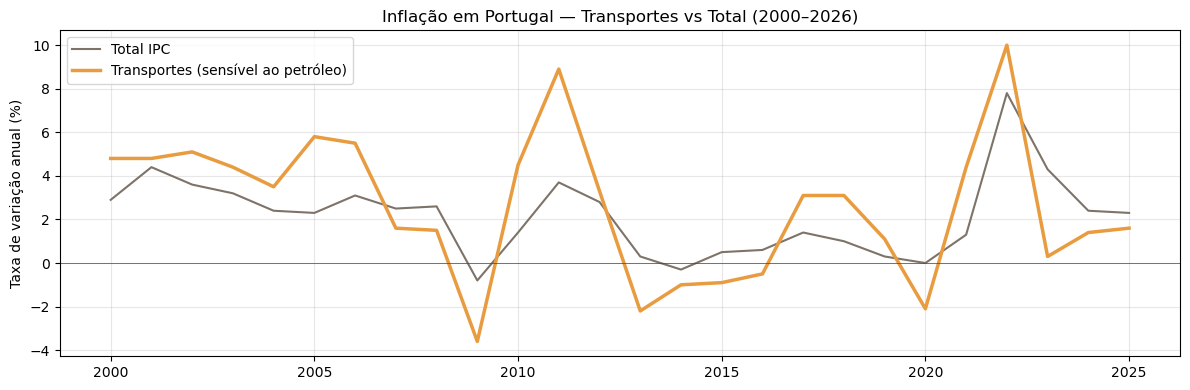

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
recent = df[df.ano >= 2000]
ax.plot(recent.ano, recent['Total'], label='Total IPC', color='#7d7368', linewidth=1.5)
ax.plot(recent.ano, recent['Transportes'], label='Transportes (sensível ao petróleo)', color='#e89c3f', linewidth=2.5)
ax.axhline(0, color='#444', linewidth=0.5)
ax.set_ylabel('Taxa de variação anual (%)')
ax.set_title('Inflação em Portugal — Transportes vs Total (2000–2026)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 5. Exportar CSV


In [6]:
out = PROCESSED / 'inflacao_pordata.csv'
df.to_csv(out, index=False)
print('✓ Gravado em', out)
print(f'  Forma: {df.shape}')


✓ Gravado em ..\data\inflacao_pordata.csv
  Forma: (66, 13)


---

## ✓ Resultado

`data/inflacao_pordata.csv` em formato *wide* (1 linha por ano, 12 colunas de classes).
Vai alimentar os **small multiples** da Secção IV (`drawInflation()` no `js/main.js`).
